In [31]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import sparse


# creates the matrices necessary for CN
def create_Apl_Ami_Heff_M2_matrices(x_vec, V_vec, Z, ell, deltaTau):
    Delta_x = x_vec[1] - x_vec[0]
    N = len(x_vec)
    
    D_lower = np.ones(N-1, dtype=complex)/(Delta_x**2)
    D_upper = np.ones(N-1, dtype=complex)/(Delta_x**2)
    D_diag = -2*np.ones(N, dtype=complex)/(Delta_x**2)
    
    D = get_sparseMatrix(D_lower, D_diag, D_upper)
    
    M_2_lower = -np.ones(N-1, dtype=complex)/6
    M_2_diag = -10*np.ones(N, dtype=complex)/6
    M_2_upper = -np.ones(N-1, dtype=complex)/6
    
    M_2 = get_sparseMatrix(M_2_lower, M_2_diag, M_2_upper)
    
    V_matrix = sparse.spdiags([V_vec], [0], N, N)
    
    # Hamiltonian (effective)
    H_2 = D + M_2@V_matrix
    
    # CN A matrices
    A_pl = M_2 + 0.5j * deltaTau * H_2
    A_mi = M_2 - 0.5j * deltaTau * H_2
    return A_pl, A_mi, H_2, M_2

def get_sparseMatrix(upper, mid, lower):
    return sparse.diags([lower, mid, upper], offsets=[-1, 0, 1], format="csr")

# Crank-Nicolson propagation
def CN_propagation(A_pl, A_mi, psi, r, N_iter=1000):
    A_pl_lower = get_lower(A_pl)
    A_pl_diag = get_diag(A_pl)
    A_pl_upper = get_upper(A_pl)
    
    for i in (range(N_iter)): # Iterate for imaginary time
        psi_new = thomas_algorithm(A_pl_lower, A_pl_diag, A_pl_upper, A_mi @ psi)
        psi = normalize(psi_new, r)
    return psi

# Compute energy (expectation value of Hamiltonian)
def calc_E_withNumerov(psi, H_2, M_2, r):
    return project(psi, H_2 @ psi, r)/project(psi, M_2 @ psi, r)


def get_diag(mat):
    return np.array([mat[i, i] for i in range(mat.shape[0])], dtype=complex)
def get_upper(mat):
    return np.array([mat[i-1, i] for i in range(1, mat.shape[0])], dtype=complex)
def get_lower(mat):
    return np.array([mat[i, i-1] for i in range(1, mat.shape[0])], dtype=complex)

# general scalar projection function
def project(psi1, psi2, x_vec):
    return np.trapz(np.conj(psi1)*psi2, x=x_vec)
def normalize(psi, x_vec):
    return psi/np.sqrt(project(psi, psi, x_vec))

def thomas_algorithm(a, b, c, d):
    n = len(b)
    
    # Create copies of the input arrays to modify during elimination
    bp = np.copy(b).astype(complex) # diagonal copy
    dp = np.copy(d).astype(complex) # Right-hand side copy
    
    # Forward elimination
    for i in range(1, n):
        # Modify the coefficients in the sub-diagonal and right-hand side
        w = a[i-1] / bp[i-1]
        bp[i] = b[i] - w * c[i-1]
        dp[i] = d[i] - w * dp[i-1]
    
    # Back substitution
    x = np.zeros(n, dtype=complex)
    x[-1] = dp[-1] / bp[-1]
    for i in range(n-2, -1, -1):
        x[i] = (dp[i] - c[i] * x[i+1]) / bp[i]
    return x

In [32]:
# loading data from previous calculations
a = np.load("a.npy")
psi0 = np.load("psi0.npy") # the eigenstate till now

# Constants, for the Hydrogen case, 2P
Z = 1
ell = 0 

# grid details
Delta_x = 0.2
N = 500
x_vec = np.linspace(-50, 50, N) 

V_softcore_vec = -1/np.sqrt(x_vec**2 + a**2)

# Imaginary time step (Δτ), based on the current energy level
delta = -0.9
E_k = -0.5
Delta_tau = 2*delta/E_k
imagDeltaTau = (-1j*Delta_tau)


# modifications applied to allow for higher excited state ITP
# psi-lowers is a list here, contains all the states to be eliminated, in each iteration of the calculations
def CN_propagation_modified2(A_pl, A_mi, psi_current , psi_lowers, r, N_iter=1000):    
    A_pl_lower = get_lower(A_pl)
    A_pl_diag = get_diag(A_pl)
    A_pl_upper = get_upper(A_pl)
    
    for i in (range(N_iter)):
        psi_forITP = psi_current # lower states to be removed from this
        
        i = 0
        for psi_lower in psi_lowers:
            # print(i, len(psi_lowers))
            i+=1
            psi_forITP = psi_forITP - project(psi_lower, psi_forITP, x_vec) * psi_lower
        
        psi_ITP_propagated = thomas_algorithm(A_pl_lower, A_pl_diag, A_pl_upper, A_mi @ psi_forITP) 
        psi_next = normalize(psi_ITP_propagated, r) 
        
        psi_current = psi_next
    return psi_current



# modification applied to allow for 1st excited state ITP
def CN_propagation_modified(A_pl, A_mi, psi_current, psi0, r, N_iter=1000):
    A_pl_lower = get_lower(A_pl)
    A_pl_diag = get_diag(A_pl)
    A_pl_upper = get_upper(A_pl)
    
    for i in (range(N_iter)):
        # psiOld = psi1_(0): Normalised ; psi1_(1): Normalised
        psi_forITP = psi_current - project(psi0, psi_current, x_vec) * psi0 #psi1_(0) : GM Orthgonalised; psi1_(1) : GM Orthogonalised
        
        psi_ITP_propagated = thomas_algorithm(A_pl_lower, A_pl_diag, A_pl_upper, A_mi @ psi_forITP) #psi1_(1) ; psi1_(2)
        psi_next = normalize(psi_ITP_propagated, r) # psi1_1: Normalised ; psi1_(2): normalised
        
        # for the next iteration
        psi_current = psi_next # psi1_1: Normalised ; psi1_(2): Normalised
    return psi_current


# modification applied to find out for 1st excited state ITP
def CN_propagation_modified(A_pl, A_mi, psi_current, psi0, r, N_iter=1000):
    A_pl_lower = get_lower(A_pl)
    A_pl_diag = get_diag(A_pl)
    A_pl_upper = get_upper(A_pl)
    
    for i in (range(N_iter)):
        # eliminate the lower states
        psi_forITP = psi_current - project(psi0, psi_current, x_vec) * psi0
        
        psi_ITP_propagated = thomas_algorithm(A_pl_lower, A_pl_diag, A_pl_upper, A_mi @ psi_forITP)
        psi_next = normalize(psi_ITP_propagated, r)
        
        # for the next iteration
        psi_current = psi_next
    return psi_current

(-0.23290360085163883-0j) (-0.23290360085163864-0j)


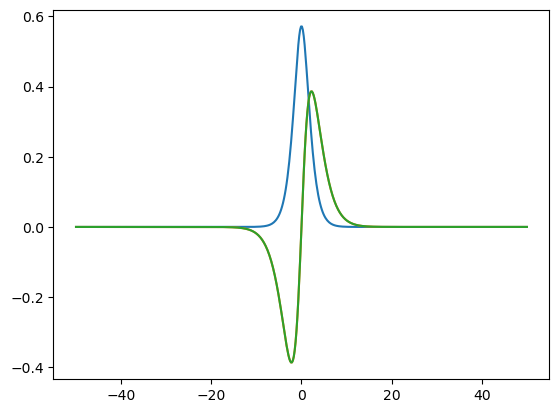

In [33]:
A_pl, A_mi, H_2, M_2 = create_Apl_Ami_Heff_M2_matrices(x_vec, V_softcore_vec, Z, ell, imagDeltaTau)

# Initial wavefunction (guessed) for the first excited state again
psi1 = np.random.random(N).astype(complex) #psi1_(0) : unnormalised
psi1 = normalize(psi1, x_vec) #psi1_(0) : normalised

psi1 = CN_propagation_modified(A_pl, A_mi, psi1, psi0, x_vec, N_iter = 1000)
psi1 = normalize(psi1, x_vec)

psi1_different = CN_propagation_modified2(A_pl, A_mi, psi1, psi_lowers=[psi0], r = x_vec, N_iter=1000)
psi1_different = normalize(psi1_different, x_vec)

plt.plot(x_vec, psi0)
plt.plot(x_vec, psi1)
plt.plot(x_vec, psi1_different)
E1 = calc_E_withNumerov(psi1, H_2, M_2, x_vec)
print(E1, calc_E_withNumerov(psi1_different, H_2, M_2, x_vec))

np.save("psi1.npy", psi1)

# alternate method to eliminate more than one lower state works for this implementation

(-0.1338290979986253-0j)


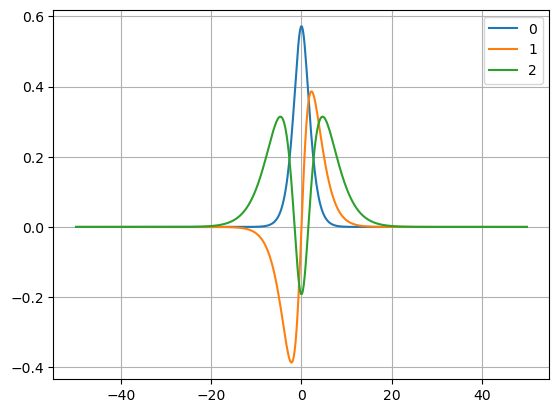

In [34]:
A_pl, A_mi, H_2, M_2 = create_Apl_Ami_Heff_M2_matrices(x_vec, V_softcore_vec, Z, ell, imagDeltaTau)

psi2 = np.random.random(N).astype(complex) 
psi2 = normalize(psi2, x_vec)

psi2 = CN_propagation_modified2(A_pl, A_mi, psi2, psi_lowers = [psi1, psi0], r = x_vec, N_iter = 1000)
psi2 = normalize(psi2, x_vec)

plt.plot(x_vec, psi0, label = "0")
plt.plot(x_vec, psi1, label = "1")
plt.plot(x_vec, psi2, label = "2")
plt.legend()
plt.grid(True)
E2 = calc_E_withNumerov(psi2, H_2, M_2, x_vec)
print(E2)

<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:40: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:40: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_7262/3354306622.py:17: SyntaxWarning: invalid escape sequence '\p'
  axs[0, 0].set_title(f"$\psi_0$; E = {calc_E_withNumerov(psi0, H_2, M_2, x_vec)}")
/tmp/ipykernel_7262/3354306622.py:24: SyntaxWarning: invalid escape sequence '\p'
  axs[0, 1].set_title(f"$\psi_1$; E = {calc_E_withNumerov(psi1, H_2, M_2, x_vec)}")
/tmp/ipykernel_7262/3354306622.py:31: SyntaxWarning: invalid escape sequence '\p'
  axs[1, 0].set_title(f"$\psi_2$; E = {calc_E_withNumerov(psi2, H_2, M_2, x_

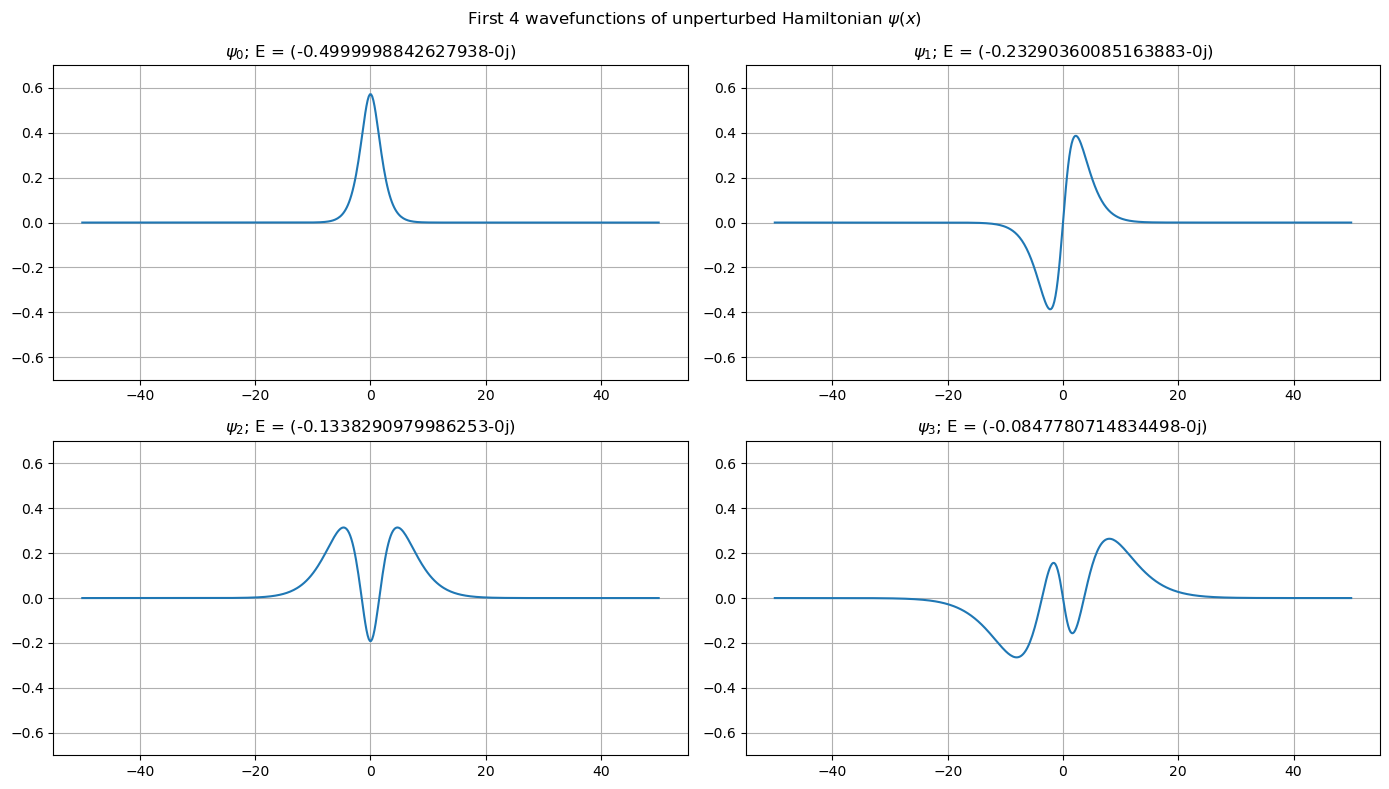

In [35]:
A_pl, A_mi, H_2, M_2 = create_Apl_Ami_Heff_M2_matrices(x_vec, V_softcore_vec, Z, ell, imagDeltaTau)

psi3 = np.random.random(N).astype(complex) 
psi3 = normalize(psi3, x_vec)

psi3 = CN_propagation_modified2(A_pl, A_mi, psi3, psi_lowers = [psi2, psi1, psi0], r = x_vec, N_iter = 1000)
psi3 = normalize(psi3, x_vec)


# Create a 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# First subplot for psi0
axs[0, 0].plot(x_vec, psi0)
axs[0, 0].grid(True)
axs[0, 0].set_ylim(-0.7, 0.7)
axs[0, 0].set_title(f"$\psi_0$; E = {calc_E_withNumerov(psi0, H_2, M_2, x_vec)}")

# Second subplot for psi1
axs[0, 1].plot(x_vec, psi1)

axs[0, 1].grid(True)
axs[0, 1].set_ylim(-0.7, 0.7)
axs[0, 1].set_title(f"$\psi_1$; E = {calc_E_withNumerov(psi1, H_2, M_2, x_vec)}")

# Third subplot for psi2
axs[1, 0].plot(x_vec, psi2)

axs[1, 0].grid(True)
axs[1, 0].set_ylim(-0.7, 0.7)
axs[1, 0].set_title(f"$\psi_2$; E = {calc_E_withNumerov(psi2, H_2, M_2, x_vec)}")

# Fourth subplot for psi3
axs[1, 1].plot(x_vec, psi3)

axs[1, 1].grid(True)
axs[1, 1].set_ylim(-0.7, 0.7)
axs[1, 1].set_title(f"$\psi_3$; E = {calc_E_withNumerov(psi3, H_2, M_2, x_vec)}")

plt.suptitle("First 4 wavefunctions of unperturbed Hamiltonian $\psi(x)$")
plt.tight_layout()
plt.show()

np.save("psi1.npy", psi1)
np.save("psi2.npy", psi2)
np.save("psi3.npy", psi3)



<>:22: SyntaxWarning: invalid escape sequence '\o'
<>:22: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_7262/3300220483.py:22: SyntaxWarning: invalid escape sequence '\o'
  plt.suptitle("Only GS before excitation \n Laser frequency $\omega = E_1 - E_0$")


Text(0, 0.5, 'Energy (in a.u.)')

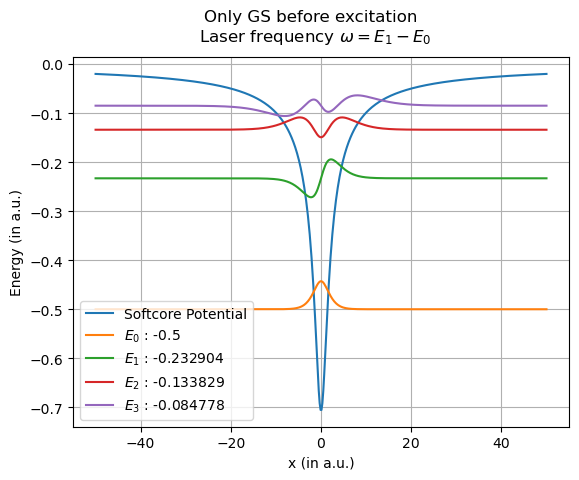

In [ ]:
# plots will be unnormalised or they will not fit
# plt.subplots( figsize=(10, 8))

E0 = np.round(np.real( calc_E_withNumerov(psi0, H_2, M_2, x_vec) ), 6)
E1 = np.round(np.real( calc_E_withNumerov(psi1, H_2, M_2, x_vec) ), 6)
E2 = np.round(np.real( calc_E_withNumerov(psi2, H_2, M_2, x_vec) ), 6)
E3 = np.round(np.real( calc_E_withNumerov(psi3, H_2, M_2, x_vec) ), 6)


plt.plot(x_vec, V_softcore_vec, label = "Softcore Potential")
plt.plot(x_vec, psi0*0.1 + E0, label = f"$E_0$ : {E0} ")
plt.plot(x_vec, psi1*0.1 + E1, label = f"$E_1$ : {E1} ")
plt.plot(x_vec, psi2*0.08 + E2, label = f"$E_2$ : {E2} ")
plt.plot(x_vec, psi3*0.08 + E3, label = f"$E_3$ : {E3} ")


# plt.plot(x_vec, np.ones_like(x_vec)*E1, "--b",label = f"$E_1$ : {np.round(np.real(E1), 6)}" )

plt.grid(True)
# plt.hlines(y = [E0,], xmin=-50, xmax=50, linestyles=["--", "--"], colors=["r","k"])
plt.legend(loc = "lower left")
# plt.suptitle("Only GS before excitation \n Laser frequency $\omega = E_1 - E_0$")
plt.title("First 4 states of the unperturbed Hamiltonian")
plt.xlabel("x (in a.u.)")
plt.ylabel("Energy (in a.u.)")